In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")


Mounted at /content/gdrive


In [ ]:
%cd /content/gdrive/MyDrive

/content/gdrive/MyDrive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# render the plot inline, instead of in a separate window
%matplotlib inline

In [ ]:
df = pd.read_csv("/content/gdrive/MyDrive/diabetes.csv")

In [ ]:
df.shape # take a look at the shape

(768, 9)

In [ ]:
df.head(5) # take a look at the first and last few lines


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.isnull().values.any() #looks like we don't have any nulls

False

In [ ]:
def plot_corr(df,size=11):
    """
    Function plots a graphical correlation matrix for each pair of columns in the dataframe.

    Input:
        df: pandas DataFrame
        size: vertical and horizontal size of the plot

    Displays:
        matrix of correlation between columns.  Yellow means that they are highly correlated.

    """
    corr = df.corr() # calling the correlation function on the datafrmae
    fig, ax = plt.subplots(figsize=(size,size))
    ax.matshow(corr) # color code the rectangles by correlation value
    plt.xticks(range(len(corr.columns)),corr.columns) # draw x tickmarks
    plt.yticks(range(len(corr.columns)),corr.columns) # draw y tickmarks

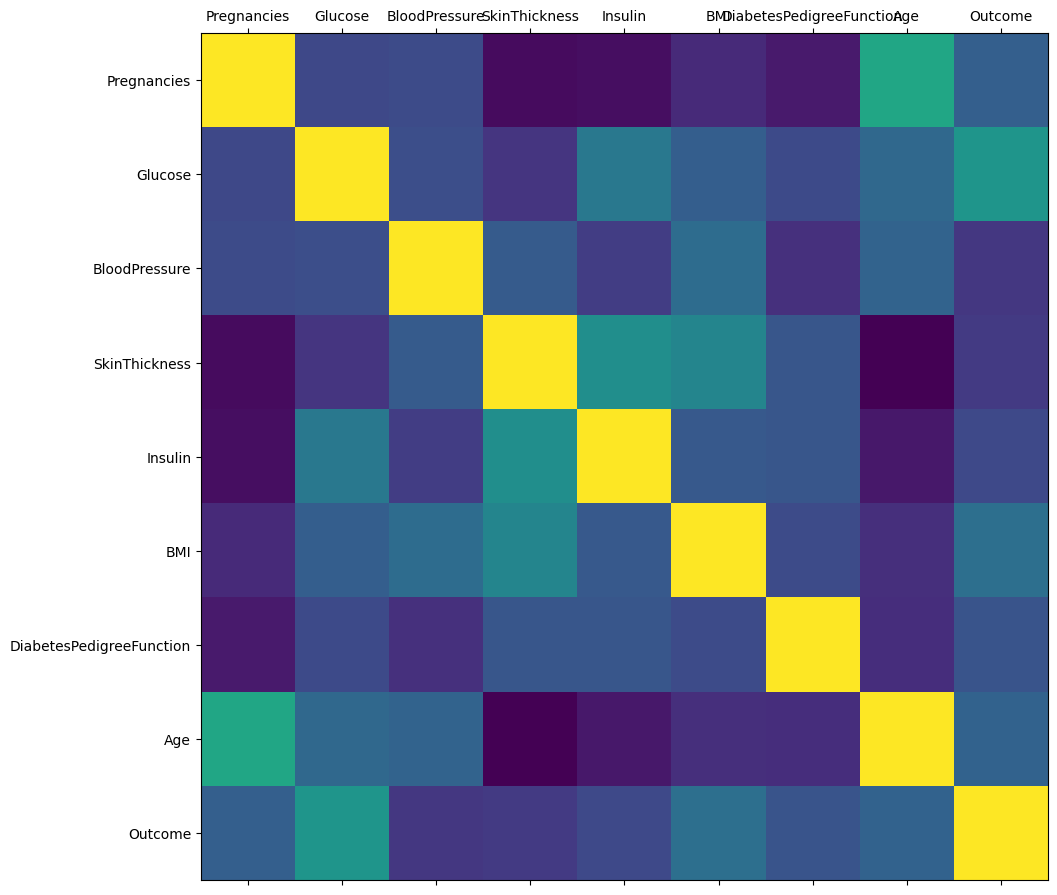

In [ ]:
plot_corr(df,size = 11)

In [ ]:
# looks like skin and thickness are highly correlated. Let's check the exact numbers for correlation
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [ ]:
num_obs = len(df)
num_true = len(df.loc[df['Outcome'] == 1])
num_false = len(df.loc[df['Outcome'] == 0])
print("Number of True cases:  {0} ({1:2.2f}%)".format(num_true, (num_true/num_obs) * 100))
print("Number of False cases: {0} ({1:2.2f}%)".format(num_false, (num_false/num_obs) * 100))

Number of True cases:  268 (34.90%)
Number of False cases: 500 (65.10%)


Splitting the Data

In [ ]:
from sklearn.model_selection import train_test_split

feature_col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
predicted_class_names = ['Outcome']

X = df[feature_col_names].values # these are factors for the prediction
y = df[predicted_class_names].values # this is what we want to predict

split_test_size = 0.3

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = split_test_size,random_state=42)
# 42 is the set.seed() equivalent in Python which generates repeatable random distribution


In [ ]:
print("{0:0.2f}% in training set".format((len(X_train)/len(df.index)) * 100))
print("{0:0.2f}% in test set".format((len(X_test)/len(df.index)) * 100))

69.92% in training set
30.08% in test set


In [ ]:
print("Original True  : {0} ({1:0.2f}%)".format(len(df.loc[df['Outcome'] == 1]), (len(df.loc[df['Outcome'] == 1])/len(df.index)) * 100.0))
print("Original False : {0} ({1:0.2f}%)".format(len(df.loc[df['Outcome'] == 0]), (len(df.loc[df['Outcome'] == 0])/len(df.index)) * 100.0))
print("")
print("Training True  : {0} ({1:0.2f}%)".format(len(y_train[y_train[:] == 1]), (len(y_train[y_train[:] == 1])/len(y_train) * 100.0)))
print("Training False : {0} ({1:0.2f}%)".format(len(y_train[y_train[:] == 0]), (len(y_train[y_train[:] == 0])/len(y_train) * 100.0)))
print("")
print("Test True      : {0} ({1:0.2f}%)".format(len(y_test[y_test[:] == 1]), (len(y_test[y_test[:] == 1])/len(y_test) * 100.0)))
print("Test False     : {0} ({1:0.2f}%)".format(len(y_test[y_test[:] == 0]), (len(y_test[y_test[:] == 0])/len(y_test) * 100.0)))


Original True  : 268 (34.90%)
Original False : 500 (65.10%)

Training True  : 188 (35.01%)
Training False : 349 (64.99%)

Test True      : 80 (34.63%)
Test False     : 151 (65.37%)


In [ ]:
from sklearn.impute import SimpleImputer

# For all readings == 0, impute with mean
fill_0 = SimpleImputer(missing_values=0, strategy="mean")

X_train= fill_0.fit_transform(X_train)
X_test = fill_0.fit_transform(X_test)


Training with Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

# create Gaussian Naive Bayes model object and train it with the data
nb_model = GaussianNB()

nb_model.fit(X_train, y_train.ravel())

GaussianNB()

In [ ]:
# predict values using training data
nb_predict_train = nb_model.predict(X_train)

# import the performance metrics library from scikit learn
from sklearn import metrics

# check naive bayes model's accuracy
print("Accuracy: {0:.4f}".format(metrics.accuracy_score(y_train,nb_predict_train)))
print()


Accuracy: 0.7542



In [ ]:
nb_predict_test=nb_model.predict(X_test)

from sklearn import metrics

print("Accuracy:{0:.4f}".format(metrics.accuracy_score(y_test,nb_predict_test)))

Accuracy:0.7359


Confusion Matrix

In [ ]:
print("Confusion Matrix")
print("{0}".format(metrics.confusion_matrix(y_test,nb_predict_test)))
print("")


Confusion Matrix
[[118  33]
 [ 28  52]]



In [ ]:
print("Classification Report")
print("{0}".format(metrics.classification_report(y_test,nb_predict_test)))

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       151
           1       0.61      0.65      0.63        80

    accuracy                           0.74       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.74      0.74       231



Naive Bayes Result
Recall is 0.65, and precision is 0.61, lower than the objective (>70%).

To improve the Precision and Recall Percentage, we'll try the:
**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model=LogisticRegression(C=0.7,random_state=42)
lr_model.fit(X_train,y_train.ravel())
lr_predict_test = lr_model.predict(X_test)

# training metrics
print("Accuracy:{0:.4f}".format(metrics.accuracy_score(y_test,lr_predict_test)))
print()
print("Confusion Matrix")
print(metrics.confusion_matrix(y_test,lr_predict_test))
print()
print("Classification Report")
print(metrics.classification_report(y_test,lr_predict_test))

Accuracy:0.7489

Confusion Matrix
[[125  26]
 [ 32  48]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       151
           1       0.65      0.60      0.62        80

    accuracy                           0.75       231
   macro avg       0.72      0.71      0.72       231
weighted avg       0.75      0.75      0.75       231



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Result
Recall is 0.55, and precision is 0.66, both are lower than the objective (>70%).

Improving **Logistic Regression Algorithm** by changing the regularization parameter(c values)

Accuracy: 0.7359

Confusion Matrix
[[123  28]
 [ 33  47]]

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       151
           1       0.63      0.59      0.61        80

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.70       231
weighted avg       0.73      0.74      0.73       231

1st max value of 0.588 occured at C=0.100


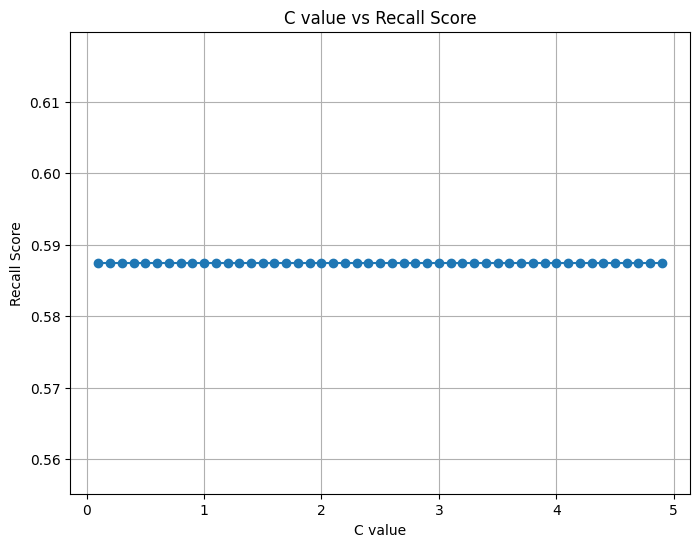

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np



# Your previous Logistic Regression model for reference
lr_model = LogisticRegression(C=0.7, random_state=42, max_iter=12)
lr_model.fit(X_train_scaled, y_train.ravel())
lr_predict_test = lr_model.predict(X_test_scaled)

# Training metrics
print("Accuracy: {:.4f}".format(metrics.accuracy_score(y_test, lr_predict_test)))
print()
print("Confusion Matrix")
print(metrics.confusion_matrix(y_test, lr_predict_test))
print()
print("Classification Report")
print(metrics.classification_report(y_test, lr_predict_test))

# Range of C values to try
C_start = 0.1
C_end = 5
C_inc = 0.1

C_values = []
recall_scores = []

C_val = C_start

best_recall_score = 0
best_lr_predict_test = None

for C_val in C_values:
    C_values.append(C_val)
    lr_model_loop = LogisticRegression(C=C_val, max_iter=12, random_state=42)
    lr_model_loop.fit(X_train, y_train.ravel())
    lr_predict_loop_test = lr_model_loop.predict(X_test)
    recall_score_val = metrics.recall_score(y_test, lr_predict_loop_test)
    recall_scores.append(recall_score_val)

    if recall_score_val > best_recall_score:
        best_recall_score = recall_score_val
        best_lr_predict_test = lr_predict_loop_test

best_score_C_val = C_values[np.argmax(recall_scores)]
print("1st max value of {0:.3f} occured at C={1:.3f}".format(best_recall_score, best_score_C_val))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(C_values, recall_scores, "-o")
plt.xlabel("C value")
plt.ylabel("Recall Score")
plt.title("C value vs Recall Score")
plt.grid(True)
plt.show()


1st max value of 0.688 occured at C=0.200


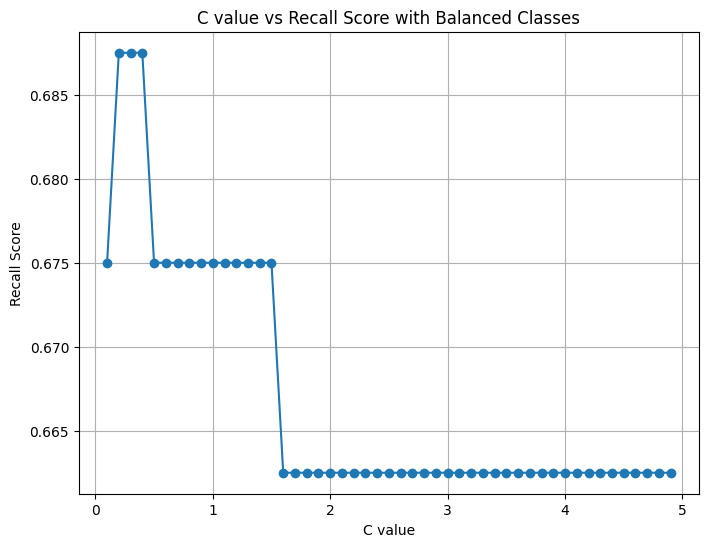

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Range of C values to try
C_start = 0.1
C_end = 5
C_inc = 0.1

C_values = np.arange(C_start, C_end, C_inc)
recall_scores = []

best_recall_score = 0
best_lr_predict_test = None

for C_val in C_values:
    lr_model_loop = LogisticRegression(C=C_val, class_weight='balanced', max_iter=10000, random_state=42)
    lr_model_loop.fit(X_train_scaled, y_train.ravel())
    lr_predict_loop_test = lr_model_loop.predict(X_test_scaled)
    recall_score_val = metrics.recall_score(y_test, lr_predict_loop_test)
    recall_scores.append(recall_score_val)

    if recall_score_val > best_recall_score:
        best_recall_score = recall_score_val
        best_lr_predict_test = lr_predict_loop_test

best_score_C_val = C_values[np.argmax(recall_scores)]
print("1st max value of {0:.3f} occured at C={1:.3f}".format(best_recall_score, best_score_C_val))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(C_values, recall_scores, "-o")
plt.xlabel("C value")
plt.ylabel("Recall Score")
plt.title("C value vs Recall Score with Balanced Classes")
plt.grid(True)
plt.show()


KNN Algo

Accuracy: 0.7013

Confusion Matrix
[[113  38]
 [ 31  49]]

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       151
           1       0.56      0.61      0.59        80

    accuracy                           0.70       231
   macro avg       0.67      0.68      0.68       231
weighted avg       0.71      0.70      0.70       231

1st max value of 0.662 occured at K=10


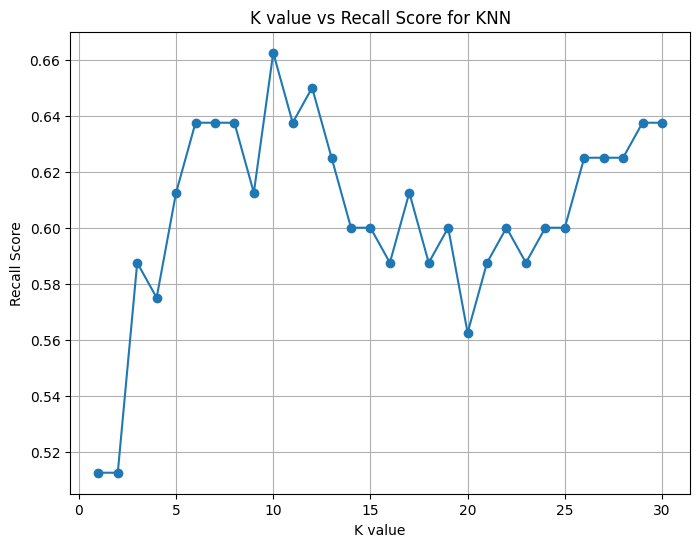

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN with weights='distance'
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train_scaled, y_train.ravel())
knn_predict_test = knn_model.predict(X_test_scaled)

# Training metrics for KNN
print("Accuracy: {:.4f}".format(metrics.accuracy_score(y_test, knn_predict_test)))
print()
print("Confusion Matrix")
print(metrics.confusion_matrix(y_test, knn_predict_test))
print()
print("Classification Report")
print(metrics.classification_report(y_test, knn_predict_test))

# Range of K values to try for plotting
K_values = range(1, 31)
recall_scores = []

best_recall_score = 0
best_knn_predict_test = None

for K in K_values:
    knn_model_loop = KNeighborsClassifier(n_neighbors=K, weights='distance')
    knn_model_loop.fit(X_train_scaled, y_train.ravel())
    knn_predict_loop_test = knn_model_loop.predict(X_test_scaled)
    recall_score_val = metrics.recall_score(y_test, knn_predict_loop_test)
    recall_scores.append(recall_score_val)

    if recall_score_val > best_recall_score:
        best_recall_score = recall_score_val
        best_knn_predict_test = knn_predict_loop_test

best_score_K_val = K_values[np.argmax(recall_scores)]
print("1st max value of {0:.3f} occured at K={1}".format(best_recall_score, best_score_K_val))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(K_values, recall_scores, "-o")
plt.xlabel("K value")
plt.ylabel("Recall Score")
plt.title("K value vs Recall Score for KNN")
plt.grid(True)
plt.show()
